In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torchvision import transforms as T

import pytorch_lightning as pl

from torchmetrics.classification import Accuracy

from datetime import datetime


from xaikd import datasets

In [7]:
ds_train = datasets.MultiTaskMNISTFashionMNIST(
    train=True,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

ds_val = datasets.MultiTaskMNISTFashionMNIST(
    train=False,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

In [11]:
ds_train[0][0].shape

torch.Size([1, 28, 56])

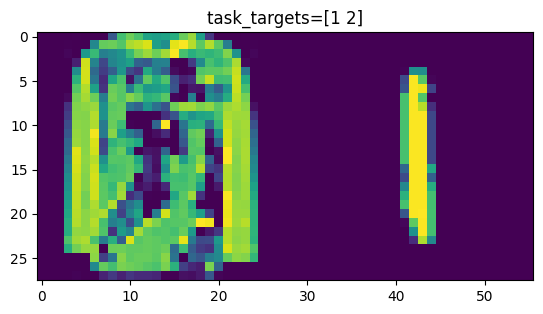

In [16]:
def ano():
    x, y = ds_train[0]
        
    plt.imshow(x.squeeze())
    plt.title(f"task_targets={y}")
ano()

# Construct Model and Train

In [33]:
class CNN(nn.Module):
    # inpsired by https://github.com/ChawDoe/LeNet5-MNIST-PyTorch/blob/master/model.py
    
    def __init__(self, num_tasks=3):
        super().__init__()
        
        d = 128
        
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        
        self.conv3 = nn.Conv2d(16, 16*2, 3)
        self.act3 = nn.ReLU()
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        self.fc_task_1 = nn.Linear(32, 10)
        self.fc_task_2 = nn.Linear(32, 10)
        
    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.pool1(x)
        
        x = self.act2(self.conv2(x))
        x = self.pool2(x)

        x = self.act3(self.conv3(x))
        
        x = self.avgpool(x)
        
        x = x.flatten(start_dim=1)

        
        task_1_out = self.fc_task_1(x)
        task_2_out = self.fc_task_2(x)
        
        return task_1_out, task_2_out
    
def ano():
    
    out = CNN()(torch.randn(10, 1, 28, 28*2))
    
    print(f"santity check")
ano()

santity check


In [32]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.SGD(
            self.parameters(), lr=self.lr, momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(2):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += 0.5*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()


In [35]:
pl.seed_everything(1)

dl_train = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=True,
)

dl_train_noshuffle = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=False,
)

dl_test = DataLoader(
    ds_val,
    batch_size=64,
    shuffle=True,
)

model  = CNN()

trainer = pl.Trainer(
    max_epochs=5
)

trainer.fit(ModelWrapper(model), dl_train, dl_test)

Global seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/pat/projects/xai-kd/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")

  | Name    | Type | Params
---------------------------------
0 | encoder | CNN  | 6.2 K 
---------------------------------
6.2 K     Trainable params
0         Non-trainable params
6.2 K     Total params
0.025     Total estimated model params size (MB)
/home/pat/projects/xai-kd/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:438: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value 

Epoch 4: 100%|█████████████| 938/938 [00:13<00:00, 70.17it/s, v_num=30, train_loss_step=2.280, train_loss_epoch=2.310]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|█████████████| 938/938 [00:13<00:00, 70.15it/s, v_num=30, train_loss_step=2.280, train_loss_epoch=2.310]


In [36]:
Accuracy?

In [38]:
def estimate_task_acc(model, dl, task_id):
    metric = Accuracy(task="multiclass", num_classes=10)
    

    for x, y in dl:
        task_logit = model(x)[task_id]
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)
    return float(metric.compute())

def compute_accs():
    
    stats = dict()
    
    for tidx in range(2):
        
        for label, dl in [
            ("train", dl_train),
            ("test", dl_test)
        ]:            
            stats[f"auroc_task_{tidx}_{label}"] = estimate_task_acc(model, dl, tidx)
    
    return stats

ref_stats = compute_accs()
ref_stats

{'auroc_task_0_train': 0.09863333404064178,
 'auroc_task_0_test': 0.0957999974489212,
 'auroc_task_1_train': 0.09984999895095825,
 'auroc_task_1_test': 0.10000000149011612}

In [9]:

def grad_hook(mod, inp, outp):
    outp.retain_grad()
    setattr(mod, "__outp", outp)

def extract_act_grad(model, dl, task_id):
    module_name = "act1"
    arr_act = []
    arr_ctx = []
    module = getattr(model, module_name)
    for x, y in dl:
                
        try:

            x.requires_grad_()
            hook = module.register_forward_hook(grad_hook)

            arr_logits = model(x)
            task_logit = arr_logits[task_id]
            task_logit.sum().backward()
        
            act = getattr(module, "__outp")
            ctx = act.grad.detach().numpy()
            act = act.detach().numpy()
            arr_act.append(act)
            arr_ctx.append(ctx)
            
            
        finally:
            hook.remove()
    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
    
    return arr_act, arr_ctx

extract_act_grad(model, dl_train_noshuffle, 0)

(array([[0.        , 0.36340228, 0.        , ..., 0.        , 0.        ,
         0.08003494],
        [0.        , 0.        , 0.59207034, ..., 0.        , 0.        ,
         0.8666073 ],
        [0.24302268, 1.8452797 , 0.        , ..., 0.8232934 , 0.        ,
         0.        ],
        ...,
        [0.        , 1.4718602 , 0.0576818 , ..., 0.87640846, 0.        ,
         0.        ],
        [0.43836653, 0.8959338 , 0.        , ..., 0.        , 0.00955817,
         0.        ],
        [0.        , 1.4817107 , 0.        , ..., 0.78739613, 0.        ,
         0.        ]], dtype=float32),
 array([[-0.0221159 ,  0.13668908,  0.07815316, ..., -0.02608113,
         -0.09538756,  0.07829081],
        [-0.0221159 ,  0.13668908,  0.07815316, ..., -0.02608113,
         -0.09538756,  0.07829081],
        [-0.0221159 ,  0.13668908,  0.07815316, ..., -0.02608113,
         -0.09538756,  0.07829081],
        ...,
        [-0.0221159 ,  0.13668908,  0.07815316, ..., -0.02608113,
         

In [10]:
def sanity_check():
    arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1, 2]:
        arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")
sanity_check()

arr_act(T0) == arr_act(T1)
arr_act(T0) == arr_act(T2)
all passed!


In [11]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs

def estimate_basis(basis_name, arr_act, arr_ctx):
    if basis_name == "pca":
        cov = arr_act.T @ arr_act
        eigvecs = _solve_eigvecs(cov)
        return eigvecs
    
    elif basis_name == "prca":
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        eigvecs = _solve_eigvecs(cov, sort_func=np.abs)
        return eigvecs
    else:
        raise

        
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return outp @ (Uk@Uk.T)
    return fh

def compute_task_auroc_at_k(model, task_id, arr_ks):
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    arr_stat_rows = []
    
    module = getattr(model, "act1")
    
    for basis_name in ["pca", "prca"]:
        U = estimate_basis(basis_name, arr_act, arr_ctx)
        for k in arr_ks:
            Uk = torch.from_numpy(U[:, :k])
            row = dict(
                task_id=task_id, 
                basis_name=basis_name,
                k=k,   
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("train", dl_train_noshuffle),
                    ("test", dl_test)
                ]:
                    row[f"auroc_{label}"] = estimate_task_auroc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
    df = pd.DataFrame(arr_stat_rows)
    
    return df

compute_task_auroc_at_k(model, task_id=0, arr_ks=np.arange(10).tolist() + [64])

,task_id,basis_name,k,auroc_train,auroc_test
0,0,pca,0,0.500000,0.500000
1,0,pca,1,0.533532,0.514276
2,0,pca,2,0.500754,0.523108
3,0,pca,3,0.501967,0.527474
4,0,pca,4,0.540190,0.523127
5,0,pca,5,0.963691,0.964417
6,0,pca,6,0.970284,0.968554
7,0,pca,7,0.992494,0.989923
8,0,pca,8,0.992519,0.989917
9,0,pca,9,0.992488,0.990161


# Accuracy Curves

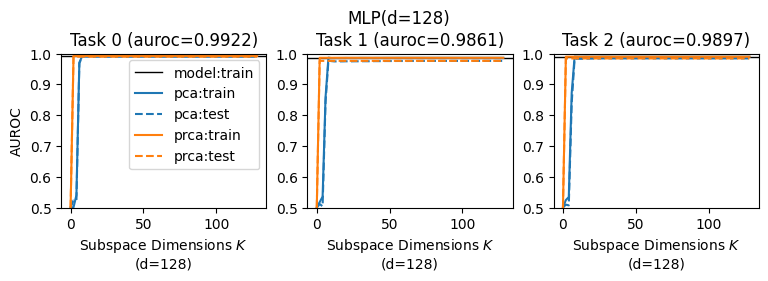

In [12]:
def viz():
    
    arr_task_ids = np.arange(3)
    plt.figure(figsize=(3*3, 2))
    
    d = model.lin1.weight.shape[0]
    arr_ks = np.linspace(0, d, d//2).astype(int)
    
    plt.suptitle(model, y=1.1)
    
    for task_id in arr_task_ids:
        plt.subplot(1, 3, task_id+1)
        
        df = compute_task_auroc_at_k(model, task_id=task_id, arr_ks=arr_ks)
        
        for basis_name in ["pca", "prca"]:
            _df = df[df.basis_name == basis_name]
            
            if basis_name == "pca":
                
                ref = _df.auroc_train.values[-1]
                plt.title(f"Task {task_id} (auroc={ref:.4f})")

                plt.axhline(
                    ref,
                    ls="-",
                    lw=1,
                    color="k",
                    label="model:train"
                )
            
            for label in ["train", "test"]:
                
                
                
                if label == "test":
                    color = plt.gca().lines[-1].get_color()
                    ls = "--"
                else:
                    color = None
                    ls = "-"
        
                plt.plot(
                    _df.k,
                    _df[f"auroc_{label}"],
                    color=color,
                    ls=ls,
                    label=f"{basis_name}:{label}"
                )
        plt.ylim([0.5, 1.0])
        if task_id == 0:
            plt.legend()
            plt.ylabel("AUROC")
        plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
viz()

# Decision Boundary

In [13]:
ref_stats

{'auroc_task_0_train': 0.9921690821647644,
 'auroc_task_0_test': 0.9897735714912415,
 'auroc_task_1_train': 0.986103892326355,
 'auroc_task_1_test': 0.9761413335800171,
 'auroc_task_2_train': 0.9897118806838989,
 'auroc_task_2_test': 0.984061598777771}

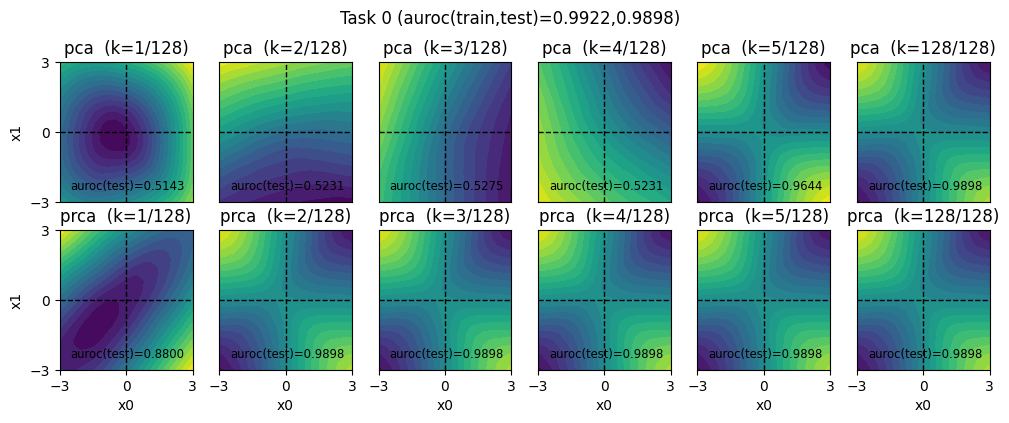

In [14]:
def decision_boundary(task_id, arr_ks=[1, 2, 3, 4, 5]):
    
    
    d = model.lin1.weight.shape[0]
    arr_ks = arr_ks + [d]
    
    nrows = 2
    ncols = len(arr_ks)
    
    arr_coords = [
        (0, 1),
        (0, 2),
        (1, 2)
    ]
    
    
    _xx = np.linspace(-3, 3, 20)
    module = getattr(model, "act1")
    plt.figure(figsize=(2*ncols, 2*nrows))
    
    auroc_train = ref_stats[f"auroc_task_{task_id}_train"]
    auroc_test = ref_stats[f"auroc_task_{task_id}_test"]
    plt.suptitle(
        f"Task {task_id} (auroc(train,test)={auroc_train:.4f},{auroc_test:.4f})",
        y=1.01
    )
    
    arr_act, arr_ctx = extract_act_grad(model, dl_train_noshuffle, task_id)
    
    for bix, basis_name in enumerate(["pca", "prca"]):
        
        U = estimate_basis(basis_name, arr_act, arr_ctx)

        coord_1, coord_2 = arr_coords[task_id]

        X = np.zeros((400, 3))
        
        xx, yy = np.meshgrid(_xx, _xx)
        
        X[:, coord_1] = xx.reshape(-1)
        X[:, coord_2] = yy.reshape(-1)
        
        X = torch.from_numpy(X).float()
        for kix, k in enumerate(arr_ks):
            Uk = torch.from_numpy(U[:, :k])
            plt.subplot(nrows, ncols, bix * ncols + kix + 1)
            plt.title(f"{basis_name}  (k={k}/{d})")
            
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                task_logits = model(X)[task_id].detach().numpy()
                
                auroc = estimate_task_auroc(
                    model,
                    dl_test,
                    task_id=task_id
                )
            
            finally:
                hook.remove()
                     
            plt.contourf(
                X[:, coord_1].reshape((20, 20)),
                X[:, coord_2].reshape((20, 20)),
                task_logits.reshape((20, 20)),
                levels=20,
            )
            
            plt.text(
                -2.5, -2.5, 
                f"auroc(test)={auroc:.4f}", 
                fontsize="small"
            )
            
            plt.axhline(0, ls="--", lw=1, color="k")
            plt.axvline(0, ls="--", lw=1, color="k")
            
            if bix == 1:
                plt.xlabel(f"x{coord_1}")
                plt.xticks([-3, 0, 3])

            else:
                plt.xticks([])
            if kix == 0:
                plt.ylabel(f"x{coord_2}")
                plt.yticks([-3, 0, 3])
            else:
                plt.yticks([])
decision_boundary(task_id=0)

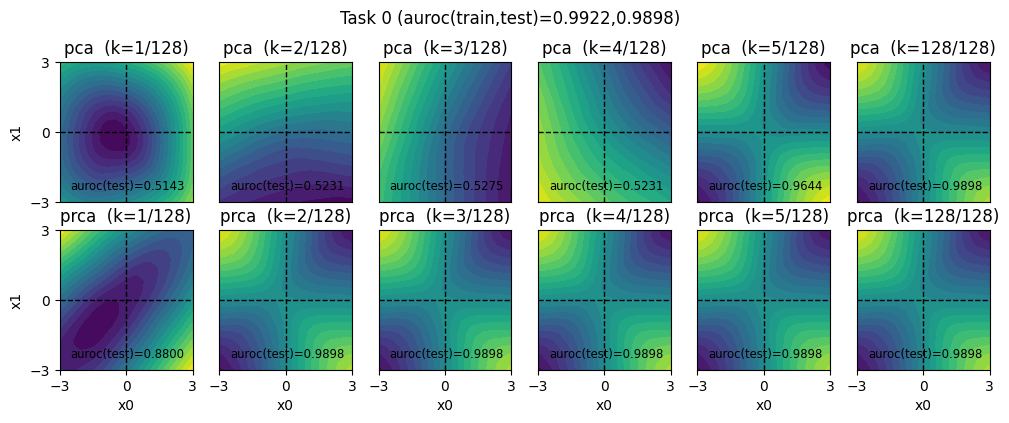

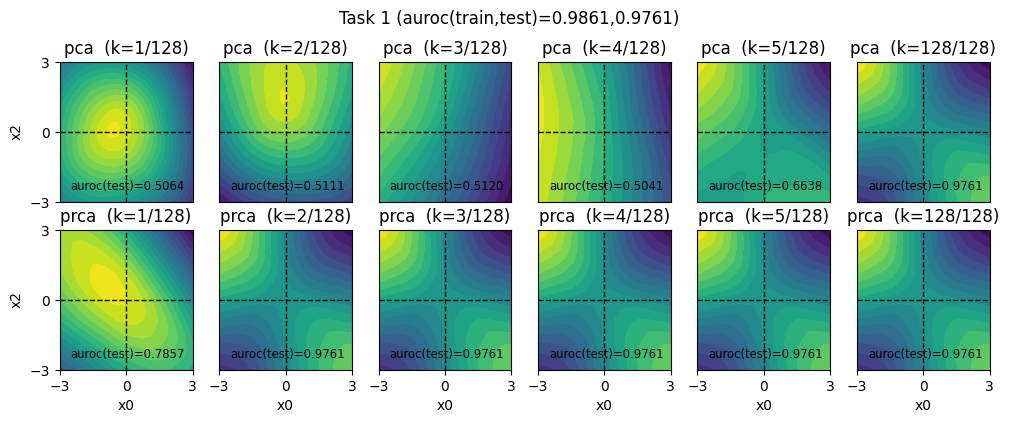

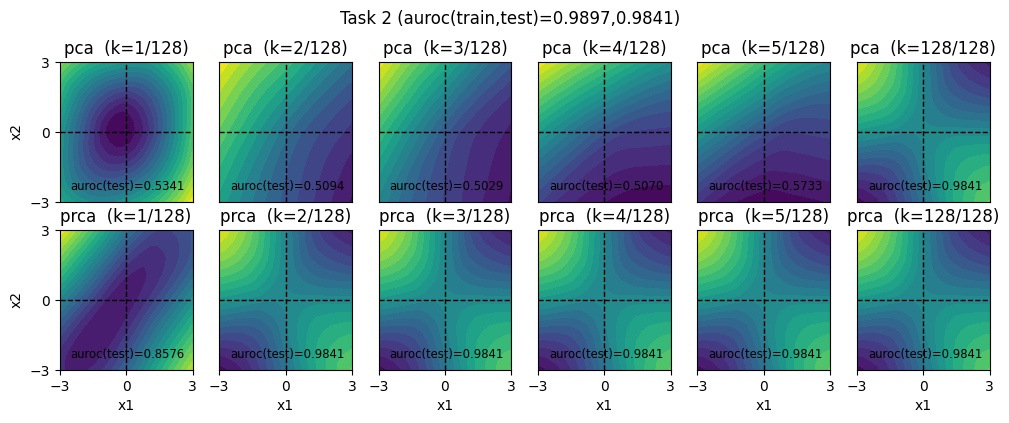

In [15]:
for task_id in range(3):
    decision_boundary(task_id=task_id)
    plt.show()

In [16]:
print(f"Finished at {datetime.now()}")

Finished at 2024-11-28 13:00:07.461841
